# Defining common integrated photonic components

This notebook contains predefined functions used to construct commonly used photonic integrated circuit (PIC) components, including straight waveguide, linear taper, ring, race track, s-bend, circular bend, and directional coupler. 

These components are defined using the [Photonforge](https://docs.flexcompute.com/projects/photonforge/en/latest/) library (`pf.Path`) as it offers a convenient and flexible way to construct curved paths with variable width. Each path is converted to a polygon via `path.to_polygon().vertices` and used to instantiate a Tidy3D [PolySlab](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PolySlab.html), which is then wrapped into a [Structure](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html). Users can directly copy these predefined functions to their own scripts and use them in building simulations. More importantly, users can learn the workflow from these examples and build their own Tidy3D Structures using the same principles.

PhotonForge also provides a complete set of tools for photonic design automation, including **PDK integration, parametric components, connectivity management, and technology definitions**. You can check the many applications of this powerful tool [here](https://docs.flexcompute.com/projects/photonforge/en/latest/examples.html).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import photonforge as pf
import tidy3d as td

## Straight Waveguide 

Straight strip waveguides are the most fundamental building block of any PIC. The function `straight_waveguide` returns a Tidy3D [Structure](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html) of a straight waveguide. The waveguide is specified by the starting position and the ending position. It only supports waveguides parallel to the $xy$ plane.

In [2]:
def straight_waveguide(x0, y0, z0, x1, y1, wg_width, wg_thickness, medium, sidewall_angle=0):
    """
    This function defines a straight strip waveguide and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of the waveguide starting position (um)
    y0: y coordinate of the waveguide starting position (um)
    z0: z coordinate of the waveguide starting position (um)
    x1: x coordinate of the waveguide end position (um)
    y1: y coordinate of the waveguide end position (um)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    medium: medium of the waveguide
    sidewall_angle: side wall angle of the waveguide (rad)
    """

    # Define the path from (x0, y0) to (x1, y1)
    path = pf.Path(origin=(x0, y0), width=wg_width)
    path.segment((x1, y1))

    # Define geometry as a PolySlab directly from the path vertices
    wg_geo = td.PolySlab(
        vertices=path.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )

    # Define tidy3d structure
    wg = td.Structure(geometry=wg_geo, medium=medium)

    return wg

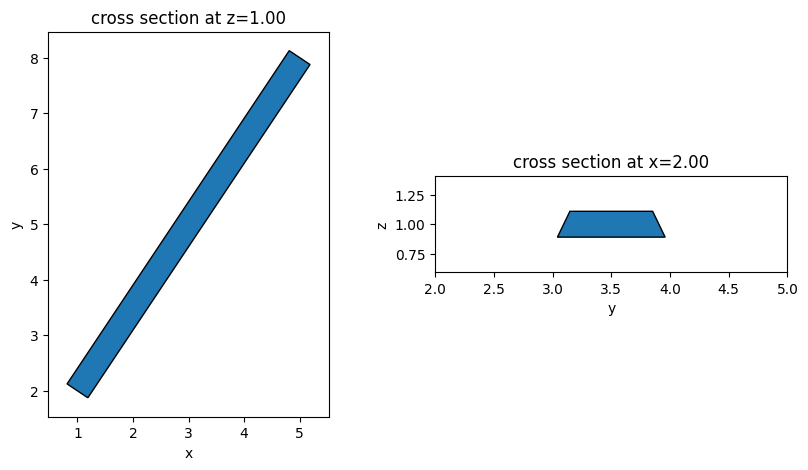

In [3]:
Si = td.material_library["cSi"]["Li1993_293K"]

wg = straight_waveguide(
    x0=1,
    y0=2,
    z0=1,
    x1=5,
    y1=8,
    wg_width=0.45,
    wg_thickness=0.22,
    medium=Si,
    sidewall_angle=15 * np.pi / 180,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
wg.plot(z=1, ax=ax1)
wg.plot(x=2, ax=ax2)
ax2.set_xlim(2, 5)
plt.show()

## Linear Waveguide Taper 

Linear waveguide tapers can be defined in a similar way. Two parameters - width at the start and width at the end of the taper, need to be specified.

In [4]:
def taper_waveguide(
    x0, y0, z0, x1, y1, wg_width_0, wg_width_1, wg_thickness, medium, sidewall_angle=0
):
    """
    This function defines a linear waveguide taper and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of the waveguide starting position (um)
    y0: y coordinate of the waveguide starting position (um)
    z0: z coordinate of the waveguide starting position (um)
    x1: x coordinate of the waveguide end position (um)
    y1: y coordinate of the waveguide end position (um)
    wg_width_0: width of the waveguide in the beginning (um)
    wg_width_1: width of the waveguide in the end (um)
    wg_thickness: thickness of the waveguide (um)
    medium: medium of the waveguide
    sidewall_angle: side wall angle of the waveguide (rad)
    """
    # Define path with linearly interpolated width from wg_width_0 to wg_width_1
    path = pf.Path((x0, y0), wg_width_0)
    path.segment((x1, y1), width=(wg_width_1, "linear"))

    # Define geometry from path vertices
    taper_geo = td.PolySlab(
        vertices=path.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )

    # Define tidy3d structure of the taper
    taper = td.Structure(geometry=taper_geo, medium=medium)

    return taper

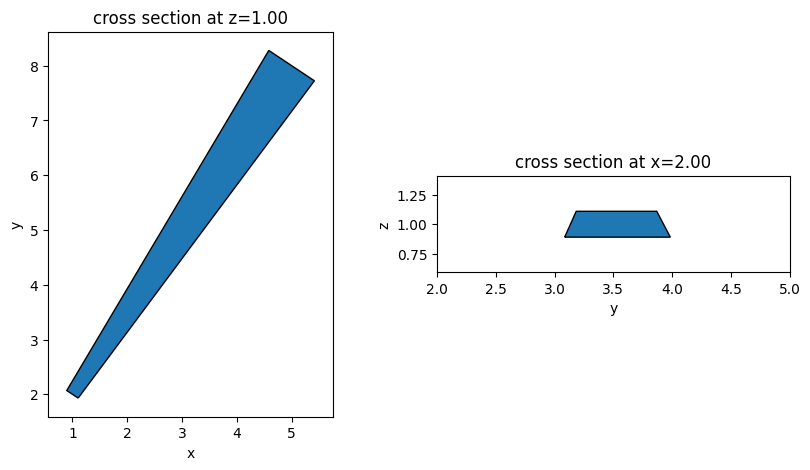

In [5]:
taper = taper_waveguide(
    x0=1,
    y0=2,
    z0=1,
    x1=5,
    y1=8,
    wg_width_0=0.25,
    wg_width_1=1,
    wg_thickness=0.22,
    medium=Si,
    sidewall_angle=15 * np.pi / 180,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
taper.plot(z=1, ax=ax1)
taper.plot(x=2, ax=ax2)
ax2.set_xlim(2, 5)
plt.show()

## Ring 

Rings are commonly used structures in PIC to construct resonators. Due to the hole, we can not define one single structure for the ring. Instead, we define two half rings and combine them to make one full ring.

In [6]:
def ring_resonator(
    x0,
    y0,
    z0,
    R,
    wg_width,
    wg_thickness,
    medium,
    sidewall_angle=0,
    reference_plane="middle",
):
    """
    This function defines a ring and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of center of the ring (um)
    y0: y coordinate of center of the ring (um)
    z0: z coordinate of center of the ring (um)
    R: radius of the ring (um)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    medium: medium of the waveguide
    sidewall_angle: side wall angle of the waveguide (rad)
    reference_plane: reference plane for the sidewall angle, either 'bottom', 'middle', or 'top'
    """
    # Top half ring: arc from 0° to 180° (counterclockwise)
    path_top = pf.Path((x0 + R, y0), wg_width)
    path_top.arc(0, 180, R)
    ring_top_geo = td.PolySlab(
        vertices=path_top.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    # Bottom half ring: arc from 0° to -180° (clockwise)
    path_bottom = pf.Path((x0 + R, y0), wg_width)
    path_bottom.arc(0, -180, R)
    ring_bottom_geo = td.PolySlab(
        vertices=path_bottom.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    # Define ring structure combining both halves
    ring = td.Structure(
        geometry=td.GeometryGroup(geometries=[ring_bottom_geo, ring_top_geo]), medium=medium
    )

    return ring

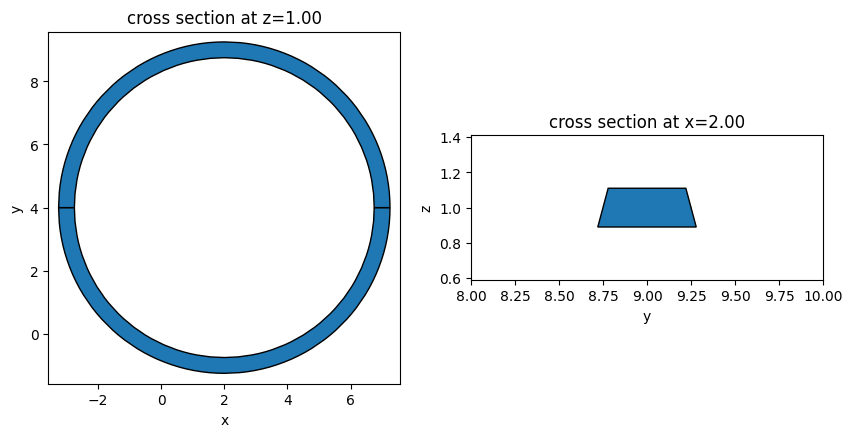

In [7]:
ring = ring_resonator(
    x0=2,
    y0=4,
    z0=1,
    R=5,
    wg_width=0.5,
    wg_thickness=0.22,
    medium=Si,
    sidewall_angle=15 * np.pi / 180,
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ring.plot(z=1, ax=ax1)
ring.plot(x=2, ax=ax2)
ax2.set_xlim(8, 10)
plt.show()

## Race Track

Similar to rings, race tracks are commonly used to construct resonators. The way to define a race track is similar to defining a ring. 

In [8]:
def race_track_resonator(
    x0,
    y0,
    z0,
    R,
    wg_length,
    wg_width,
    wg_thickness,
    medium,
    sidewall_angle=0,
    reference_plane="middle",
):
    """
    This function defines a race track and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of center of the race track (um)
    y0: y coordinate of center of the race track (um)
    z0: z coordinate of center of the race track (um)
    R: radius of the circular part (um)
    wg_length: length of the straight waveguide (um)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    medium: medium of the waveguide
    sidewall_angle: side wall angle of the waveguide (rad)
    reference_plane: reference plane for the sidewall angle, either 'bottom', 'middle', or 'top'
    """
    x_start = x0 + wg_length / 2 + R

    # Top half: right quarter arc → top straight segment → left quarter arc
    path_top = pf.Path((x_start, y0), wg_width)
    path_top.arc(0, 90, R)  # right quarter arc (0° → 90°)
    path_top.segment((x0 - wg_length / 2, y0 + R))  # top straight segment
    path_top.arc(90, 180, R)  # left quarter arc (90° → 180°)
    race_track_top_geo = td.PolySlab(
        vertices=path_top.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    # Bottom half: right quarter arc → bottom straight segment → left quarter arc
    path_bottom = pf.Path((x_start, y0), wg_width)
    path_bottom.arc(0, -90, R)  # right quarter arc (0° → -90°)
    path_bottom.segment((x0 - wg_length / 2, y0 - R))  # bottom straight segment
    path_bottom.arc(-90, -180, R)  # left quarter arc (-90° → -180°)
    race_track_bottom_geo = td.PolySlab(
        vertices=path_bottom.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    # Define race track structure combining both halves
    race_track = td.Structure(
        geometry=td.GeometryGroup(geometries=[race_track_bottom_geo, race_track_top_geo]),
        medium=medium,
    )

    return race_track

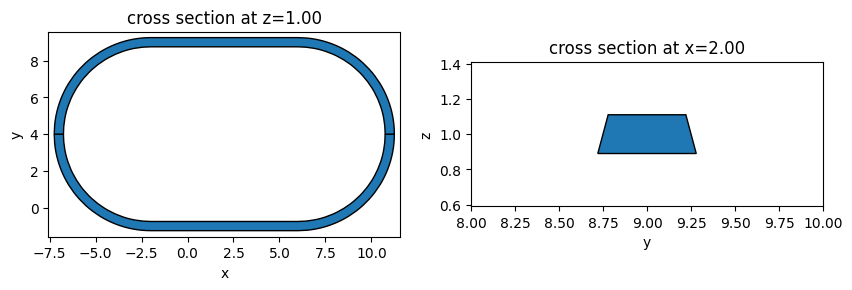

In [9]:
race_track = race_track_resonator(
    x0=2,
    y0=4,
    z0=1,
    R=5,
    wg_length=8,
    wg_width=0.5,
    wg_thickness=0.22,
    medium=Si,
    sidewall_angle=15 * np.pi / 180,
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
race_track.plot(z=1, ax=ax1)
race_track.plot(x=2, ax=ax2)
ax2.set_xlim(8, 10)
plt.show()

## Waveguide Cosine S-bend

Waveguide s-bends are commonly used in various PIC devices. The function `cosine_sbend` defines an s-bend using the `pf.Path.s_bend()` method, which internally uses a cosine profile to smoothly connect two points. The bend direction can be controlled by the `mirror` parameter, and the `orientation` parameter selects whether the bend propagates along the $x$ or $y$ direction.

In [10]:
def cosine_sbend(
    x0,
    y0,
    z0,
    wg_width,
    wg_thickness,
    bend_length,
    bend_height,
    medium,
    orientation="x",
    mirror=False,
    sidewall_angle=0,
):
    """
    This function defines a cosine waveguide bend and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of the bend starting position (um)
    y0: y coordinate of the bend starting position (um)
    z0: z coordinate of the bend starting position (um)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    bend_length: length of the bend (um)
    bend_height: height of the bend (um)
    medium: medium of the waveguide
    orientation: orientation of the bend, either 'x' or 'y'
    mirror: whether to mirror bend (reverses the transverse direction)
    sidewall_angle: side wall angle of the waveguide (rad)
    """
    path = pf.Path((x0, y0), wg_width)

    if orientation == "x":
        # S-bend from (x0, y0) to (x0+bend_length, y0 ± bend_height)
        end_y = y0 - bend_height if mirror else y0 + bend_height
        path.s_bend((x0 + bend_length, end_y))

    elif orientation == "y":
        # S-bend from (x0, y0) to (x0 ± bend_height, y0+bend_length)
        end_x = x0 - bend_height if mirror else x0 + bend_height
        path.s_bend((end_x, y0 + bend_length))

    # Define geometry from path vertices
    bend_geo = td.PolySlab(
        vertices=path.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )

    # Define tidy3d structure of the bend
    bend = td.Structure(geometry=bend_geo, medium=medium)

    return bend

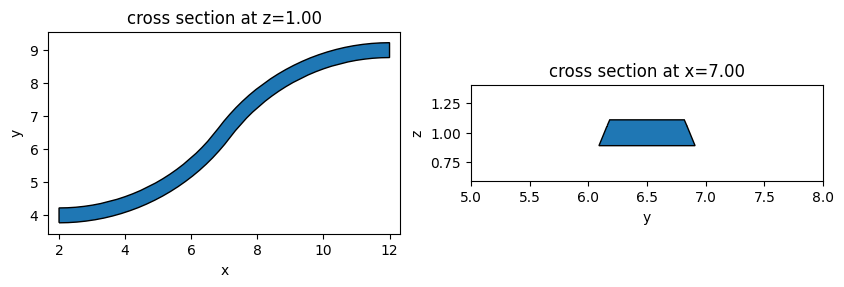

In [11]:
bend = cosine_sbend(
    x0=2,
    y0=4,
    z0=1,
    wg_width=0.45,
    wg_thickness=0.22,
    bend_length=10,
    bend_height=5,
    medium=Si,
    orientation="x",
    mirror=False,
    sidewall_angle=15 * np.pi / 180,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
bend.plot(z=1, ax=ax1)
bend.plot(x=7, ax=ax2)
ax2.set_xlim(5, 8)
plt.show()

## Waveguide Circular Bend

Circular bends with an arbitrary bending angle and radius can be defined using the `circular_bend` function. Similar to the s-bend, the circular bend here interfaces with waveguides in the $x$ or $y$ direction and its bend direction can be controlled by the `mirror` parameter.

In [12]:
def circular_bend(
    x0,
    y0,
    z0,
    R,
    bend_angle,
    wg_width,
    wg_thickness,
    medium,
    orientation="x",
    mirror=False,
    sidewall_angle=0,
):
    """
    This function defines a circular waveguide bend and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of the bend starting position (um)
    y0: y coordinate of the bend starting position (um)
    z0: z coordinate of the bend starting position (um)
    R: radius of the circular bend (um)
    bend_angle: angle of the bend (rad)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    medium: medium of the waveguide
    orientation: orientation of the bend, either 'x' or 'y'
    mirror: whether to mirror bend
    sidewall_angle: side wall angle of the waveguide (rad)
    """
    # Convert bend_angle from radians to degrees for pf.Path.arc
    bend_angle_deg = np.degrees(bend_angle)

    path = pf.Path((x0, y0), wg_width)

    if orientation == "x":
        # Arc starting at -90° (path going in +x direction), sweeping by bend_angle
        path.arc(-90, -90 + bend_angle_deg, R)
        if mirror:
            path.mirror((x0 + 1, y0), (x0, y0))

    elif orientation == "y":
        # Arc starting at 180° (path going in +y direction), sweeping by -bend_angle
        path.arc(180, 180 - bend_angle_deg, R)
        if mirror:
            path.mirror((x0, y0 + 1), (x0, y0))

    # Define geometry from path vertices
    bend_geo = td.PolySlab(
        vertices=path.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )

    # Define tidy3d structure of the bend
    bend = td.Structure(geometry=bend_geo, medium=medium)

    return bend

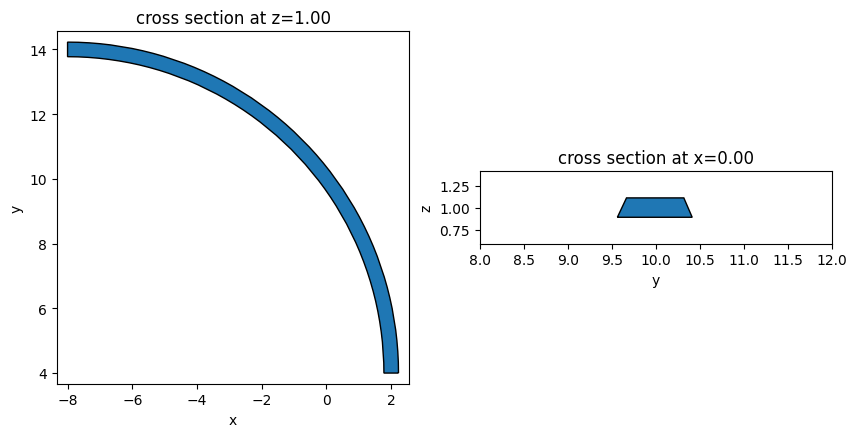

In [13]:
bend = circular_bend(
    x0=2,
    y0=4,
    z0=1,
    R=10,
    bend_angle=np.pi / 2,
    wg_width=0.45,
    wg_thickness=0.22,
    medium=Si,
    orientation="y",
    mirror=True,
    sidewall_angle=15 * np.pi / 180,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
bend.plot(z=1, ax=ax1)
bend.plot(x=0, ax=ax2)
ax2.set_xlim(8, 12)
plt.show()

## Directional Coupler 

A directional coupler (DC) composes of two waveguides brought into close proximity for a certain length. The function `directional_coupler` defines a symmetric DC.

In [14]:
def directional_coupler(
    x0,
    y0,
    z0,
    wg_width,
    wg_thickness,
    wg_spacing_in,
    wg_spacing_coup,
    wg_length,
    coup_length,
    bend_length,
    medium,
    sidewall_angle=0,
):
    """
    This function defines a directional coupler and returns the tidy3d structure of it.

    Parameters
    ----------
    x0: x coordinate of directional coupler center (um)
    y0: y coordinate of directional coupler center (um)
    z0: z coordinate of directional coupler center (um)
    wg_width: width of the waveguide (um)
    wg_thickness: thickness of the waveguide (um)
    wg_spacing_in : spacing between the input straight waveguides (um)
    wg_spacing_coup: gap size of the coupling region (um)
    wg_length: length of the input straight waveguides (um)
    coup_length: length of the coupling region (um)
    bend_length: length of the bending (um)
    medium: medium of the waveguide
    sidewall_angle: side wall angle of the waveguide (rad)
    """
    # Y positions: input/output and coupling region
    y_in = wg_spacing_in / 2 + y0
    y_coup = (
        y0 + (wg_spacing_coup + wg_width) / 2
    )  # center-to-center gap = wg_spacing_coup + wg_width

    # X positions
    x_start = x0 - wg_length - bend_length - coup_length / 2
    x_bend_in_end = x0 - coup_length / 2
    x_bend_out_start = x0 + coup_length / 2
    x_end = x0 + wg_length + bend_length + coup_length / 2

    # Upper waveguide: straight in → s-bend approach → coupling → s-bend exit → straight out
    path_top = pf.Path((x_start, y_in), wg_width)
    path_top.segment((x_start + wg_length, y_in))  # straight input
    path_top.s_bend((x_bend_in_end, y_coup))  # smooth approach to coupling gap
    path_top.segment((x_bend_out_start, y_coup))  # coupling region
    path_top.s_bend((x_bend_out_start + bend_length, y_in))  # smooth exit from coupling gap
    path_top.segment((x_end, y_in))  # straight output

    # Lower waveguide: mirror of upper around y=y0
    path_bottom = path_top.copy().mirror((x0 + 1, y0), (x0, y0))

    # Convert paths to PolySlab geometries
    dc_top_geo = td.PolySlab(
        vertices=path_top.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )
    dc_bottom_geo = td.PolySlab(
        vertices=path_bottom.to_polygon().vertices,
        axis=2,
        slab_bounds=(z0 - wg_thickness / 2, z0 + wg_thickness / 2),
        sidewall_angle=sidewall_angle,
    )

    # Define tidy3d structure of the directional coupler
    dc = td.Structure(
        geometry=td.GeometryGroup(geometries=[dc_top_geo, dc_bottom_geo]), medium=medium
    )

    return dc

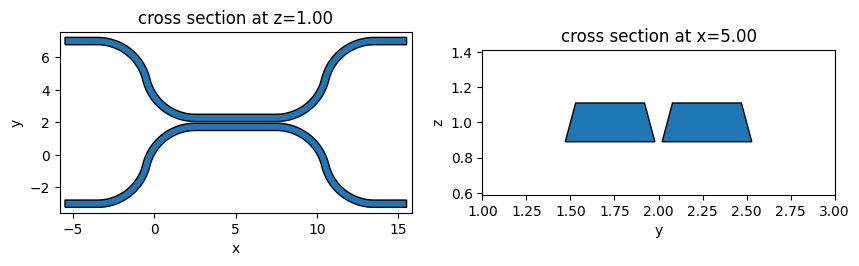

In [15]:
dc = directional_coupler(
    x0=5,
    y0=2,
    z0=1,
    wg_spacing_in=10,
    wg_width=0.45,
    wg_thickness=0.22,
    wg_spacing_coup=0.1,
    coup_length=5,
    bend_length=6,
    wg_length=2,
    medium=Si,
    sidewall_angle=15 * np.pi / 180,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
dc.plot(z=1, ax=ax1)
dc.plot(x=5, ax=ax2)
ax2.set_xlim(1, 3)
plt.show()

## Multimode Interference (MMI) Coupler

A multimode interference (MMI) coupler consists of a wide multimode waveguide connected to single-mode input and output waveguides via s-bends. Power splitting occurs through the self-imaging effect: the multimode region supports many guided modes whose interference pattern reproduces the input field at periodic distances along the propagation direction. The function `make_mmi_shape` builds a symmetric 2×2 MMI and returns the Tidy3D [PolySlab](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PolySlab.html) geometry, which can then be wrapped into a [Structure](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html).

In [16]:
def make_mmi_shape(
    l_mmi,
    w_mmi,
    w_wg,
    s_bend_length,
    s_bend_offset,
    center=(0, 0),
    slab_bounds=(-0.11, 0.11),
    sidewall_angle=0,
    reference_plane="top",
):
    """
    Build a symmetric 2x2 MMI coupler and return its Tidy3D PolySlab geometry.

    The MMI body is a rectangle of size (l_mmi, w_mmi) centered at the origin.
    Four s-bend waveguides are attached symmetrically: two at the input (left)
    and two at the output (right) faces. All parts are merged into a single
    polygon via boolean union before creating the PolySlab. The resulting
    geometry must be wrapped in a td.Structure by the caller.

    Parameters
    ----------
    l_mmi: length of the MMI multimode region (um)
    w_mmi: width of the MMI multimode region (um)
    w_wg: width of the access waveguides (um)
    s_bend_length: longitudinal length of the s-bend transitions (um)
    s_bend_offset: transverse offset of the s-bends — controls port separation
        at the input/output relative to the MMI edge (um)
    center: (x, y) position of the MMI center (um)
    slab_bounds: (z_min, z_max) of the slab in the z direction (um)
    sidewall_angle: sidewall angle of the waveguide (rad)
    reference_plane: reference plane for the sidewall angle, either 'bottom', 'middle', or 'top'
    """
    # MMI multimode region: rectangle centered at the origin
    mmi = pf.Rectangle(size=(l_mmi, w_mmi))

    # Access waveguides connect at the top and bottom edges of the MMI face
    x_out = l_mmi / 2  # x position of the output face
    y_out = w_mmi / 2 - w_wg / 2  # y offset: waveguide centered near the MMI edge

    # Output upper s-bend: starts at the output face, bends upward
    bend_out_up = pf.Path(origin=(x_out, y_out), width=w_wg)
    bend_out_up.s_bend((s_bend_length, s_bend_offset), relative=True)
    bend_out_up.segment((10, 0), relative=True)  # straight output section

    # Output lower s-bend: mirror of upper across the x-axis
    bend_out_down = bend_out_up.copy().mirror()

    # Input upper s-bend: mirror of output upper across the y-axis
    bend_in_up = bend_out_up.copy().mirror((0, 1))

    # Input lower s-bend: mirror of output lower across both axes
    bend_in_down = bend_out_down.copy().mirror((0, 1))

    # Boolean union of all parts into a single connected polygon
    polygons = pf.boolean(
        [
            mmi,
            bend_out_up,
            bend_out_down,
            bend_in_up,
            bend_in_down,
        ],
        [],
        "+",
    )

    assert len(polygons) == 1, "Expected a single polygon for the union."
    polygon = polygons[0]
    assert len(polygon.holes) == 0, "Expected no holes."

    # Translate to the requested center position
    polygon.translate(center)

    geometry = td.PolySlab(
        vertices=polygon.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    return geometry

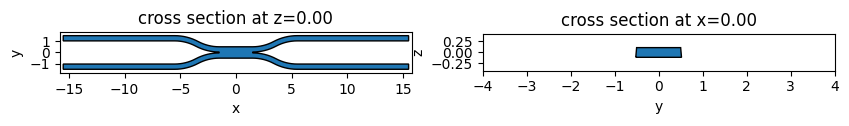

In [17]:
mmi_geo = make_mmi_shape(
    l_mmi=3,
    w_mmi=1,
    w_wg=0.45,
    s_bend_length=4,
    s_bend_offset=1,
    center=(0, 0),
    slab_bounds=(-0.11, 0.11),
    sidewall_angle=5 * np.pi / 180,
    reference_plane="top",
)

mmi = td.Structure(geometry=mmi_geo, medium=Si)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
mmi.plot(z=0, ax=ax1)
mmi.plot(x=0, ax=ax2)
ax2.set_xlim(-4, 4)
plt.show()